In [440]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [441]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
data = pd.read_csv(url, usecols=[1])
data.columns = ['Passengers']

scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)


In [459]:
# Fungsi Dataset Supervised

def create_dataset(dataset, time_step=20):
    X, y = [], []
    for i in range(len(dataset) - time_step - 1):
        X.append(dataset[i:(i + time_step), 0])
        y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 20
X, y = create_dataset(data_scaled, time_step)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Split train/test
train_size = int(len(X) * 0.7)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [465]:
# Model RNN dengan activation relu
model = Sequential([
    SimpleRNN(50, activation='relu',return_sequences=True,input_shape=(time_step, 1)),
    SimpleRNN(30,activation='relu', return_sequences=False),
    Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')

# Callback: early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Latih model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=16,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/100


c:\Users\Hary Capri\anaconda3\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0488 - val_loss: 0.0397
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0069 - val_loss: 0.0166
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0075 - val_loss: 0.0258
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0067 - val_loss: 0.0251
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0053 - val_loss: 0.0165
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0051 - val_loss: 0.0139
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0045 - val_loss: 0.0133
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0039 - val_loss: 0.0129
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0031 - val_loss: 0.0110
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0037 - val_loss: 0.0089
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0024 - val_loss: 0.0081
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0025 - val_loss: 0.0073
E

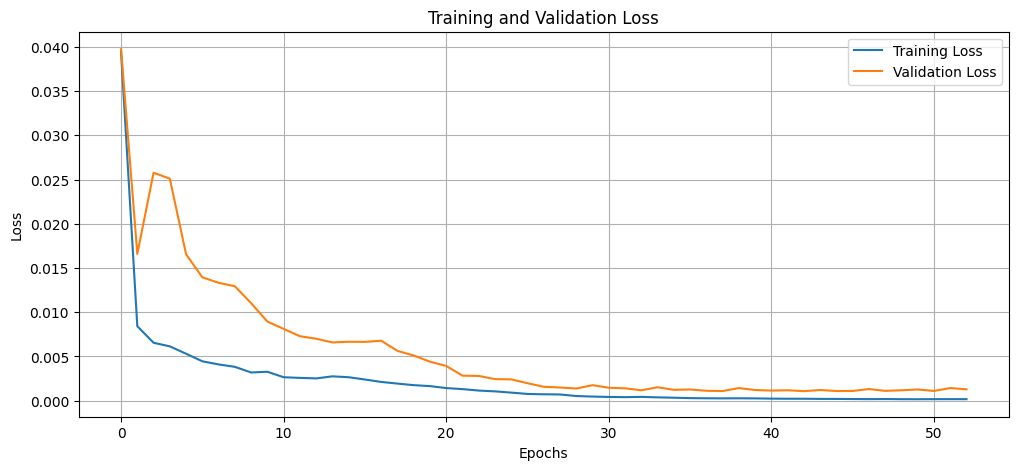

In [ ]:
# Plot Training Loss

plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Hitung dan Tampilkan Rata-rata Loss

avg_train_loss = np.mean(history.history['loss'])
avg_val_loss = np.mean(history.history['val_loss'])

print(f"Rata-Rata Training Loss : {avg_train_loss}")
print(f"Rata-Rata Validation Loss: {avg_val_loss}")
print("-"*40)

Rata-Rata Training Loss : 0.0023055272097238077
Rata-Rata Validation Loss: 0.0056377883367943315
----------------------------------------


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


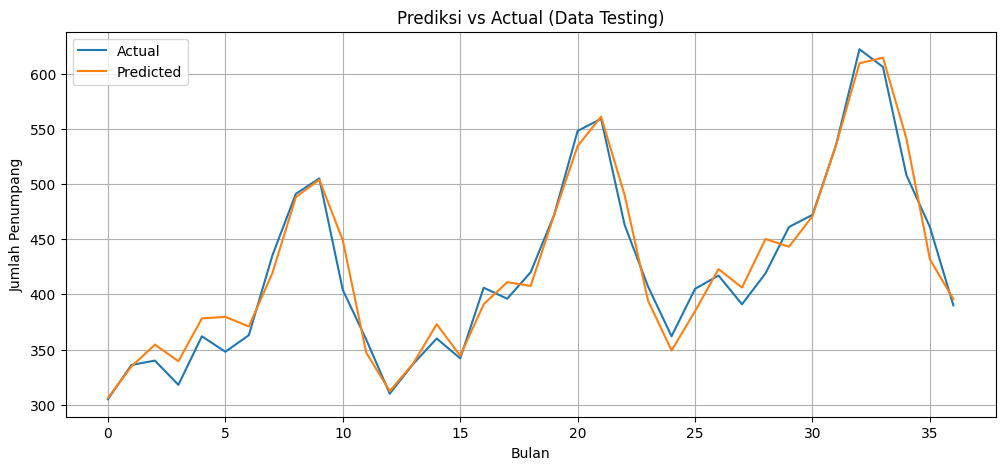

In [ ]:
# Plot Prediksi di Data Test (Actual vs Predicted)

predictions = model.predict(X_test)
predictions_inverse = scaler.inverse_transform(predictions)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

plt.figure(figsize=(12, 5))
plt.plot(y_test_inverse, label='Actual')
plt.plot(predictions_inverse, label='Predicted')
plt.title('Prediksi vs Actual (Data Testing)')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Penumpang')
plt.legend()
plt.grid(True)
plt.show()

In [469]:
# Prediksi di data test
y_pred = model.predict(X_test)

# Invers transformasi ke skala asli
y_pred_inverse = scaler.inverse_transform(y_pred.reshape(-1, 1))
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

# Hitung metrik
mae = mean_absolute_error(y_test_inverse, y_pred_inverse)
rmse = np.sqrt(mean_squared_error(y_test_inverse, y_pred_inverse))
r2 = r2_score(y_test_inverse, y_pred_inverse)

print(f"Mean Absolute Error (MAE): {mae:.2f} penumpang")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} penumpang")
print(f"R² Score: {r2:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Mean Absolute Error (MAE): 12.99 penumpang
Root Mean Squared Error (RMSE): 16.95 penumpang
R² Score: 0.9562


In [ ]:
#  Prediksi 12 Bulan ke Depan (Recursive Forecasting)
forecast = []

last_input = data_scaled[-time_step:].flatten()

for _ in range(12):
    input_reshaped = last_input.reshape((1, time_step, 1))
    predicted = model.predict(input_reshaped, verbose=0)
    forecast.append(predicted[0, 0])
    # Geser window
    last_input = np.roll(last_input, -1)
    last_input[-1] = predicted

# Invers transformasi
forecast_inverse = scaler.inverse_transform(np.array(forecast).reshape(-1, 1))


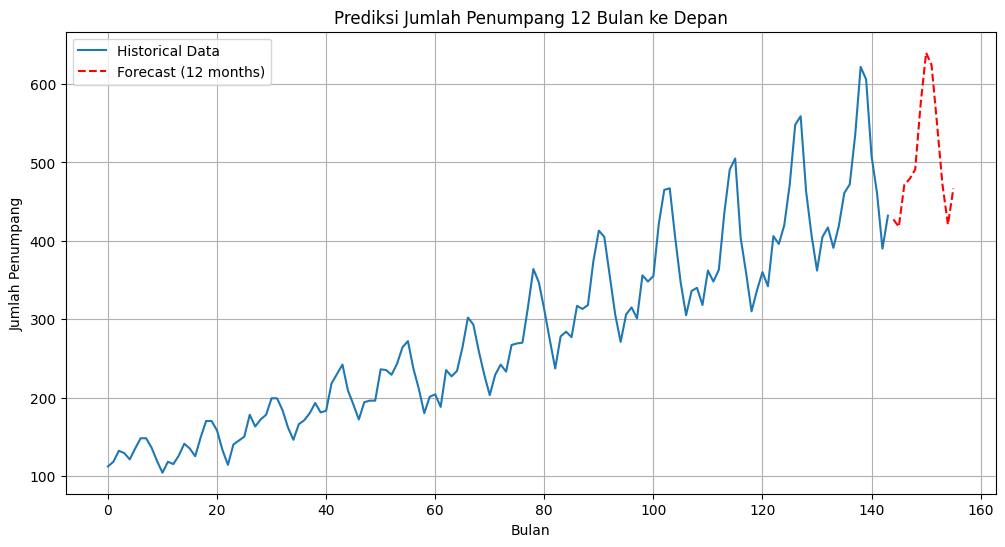

In [457]:
# Visualisasi Hasil Forecast

plt.figure(figsize=(12, 6))
plt.plot(data, label='Historical Data')
plt.plot(np.arange(len(data), len(data)+12), forecast_inverse, label='Forecast (12 months)', color='red', linestyle='--')
plt.title('Prediksi Jumlah Penumpang 12 Bulan ke Depan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Penumpang')
plt.legend()
plt.grid(True)
plt.show()

In [470]:
# Tampilkan Hasil dalam Format Tabel

forecast_df = pd.DataFrame(forecast_inverse, columns=['Forecast'], 
                           index=range(len(data), len(data)+12))
print("\nPrediksi Jumlah Penumpang (12 Bulan ke Depan):")
print(forecast_df)


Prediksi Jumlah Penumpang (12 Bulan ke Depan):
       Forecast
144  427.334930
145  417.944977
146  471.188049
147  479.198517
148  490.989319
149  574.810425
150  640.037781
151  624.279968
152  549.616211
153  471.698364
154  420.674530
155  466.847168
